> ⚠️ **Nota de versión (2026-06-17).** Este cuaderno registra la **ELECCIÓN del activo** (Fase 2) con el
> protocolo **inicial** (embargo=5, accuracy headline 0.524). Tras adoptar **embargo=1** (Decisión #15, por
> principio: horizonte de etiqueta=1), la cifra headline pasó a **0.552** y el análisis completo y vigente
> está en **`notebooks/m10_better_smci.ipynb`**. Recorrido entero: `docs/chats/decision_activo/smci.md`. El
> **veredicto cualitativo no cambia** (SMCI = único activo donde M10 bate a M5/M8/B&H nominal). Las cifras de
> abajo (0.524 / embargo 5) son las del estudio de elección; las **vigentes** son las de embargo=1.

# Decisión del activo del caso de estudio — registro

**TFG STRATA · Raquel García.** Este cuaderno registra, de forma trazable, las decisiones para elegir el
**activo del caso de estudio** y la **configuración del modelo**, con los gráficos en los que se basó la
elección. Las cifras se leen de `outputs/experiments/smci_config_study.json` (no se recomputan aquí).

## Decisión: **SMCI** (Super Micro Computer)

**Por qué SMCI y no SPY/NVDA:** el tribunal puede tumbar un modelo de trading si una **estrategia trivial**
(comprar-y-mantener, B&H = "siempre largo") lo bate. Eso pasa en activos alcistas (SPY B&H ≈ 0.57). La
defensa correcta —indicada por el tutor— es elegir un activo donde **B&H ≈ 50 %** (sin deriva regalada), de
modo que batir al pasivo requiera **habilidad direccional real**. En SMCI **B&H ≈ 0.48** → benchmark justo.

**Y en SMCI el modelo gana siendo DESPLEGABLE:** el M10 walk-forward (entrenado solo con el pasado) es la
estrategia más acertada, por encima del agente, de la regla y del pasivo — y por encima incluso de su propia
versión CPCV (que ve el futuro). Es decir, el buen resultado **no** viene de mirar el futuro.

## §1 · Protocolo train/test (desplegable, con burn-in)

No es un split único: es **walk-forward de ventana expandible**, que simula el uso diario real:

- **Burn-in = 150 días**: entrenamiento inicial. **NO se puntúa** (no entra en la accuracy).
- **Reentreno mensual** (cada 21 días): cada mes se reentrena con **todo el pasado disponible** y se predice
  el mes siguiente. **Solo pasado** → sin look-ahead.
- **Embargo = 5 días** entre el fin del train y el inicio del test (evita fuga por solape de etiquetas).
- Se evalúa del día 151 al final (~250 días), cada día predicho por un modelo que solo vio el pasado.

**CPCV descartado para despliegue:** la validación cruzada combinatoria entrena con bloques cronológicamente
**futuros** → da una estimación insesgada de *backtest*, pero **no simula producción**. Se muestra solo como
contraste (y en SMCI es además peor que el walk-forward).

In [1]:
import json, os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

_ROOT = Path.cwd() if (Path.cwd() / "config.py").exists() else Path.cwd().parent
os.chdir(_ROOT)                                   # ejecutar desde la raíz del repo (rutas relativas)
S = json.load(open("outputs/experiments/smci_config_study.json"))
meta = S["meta"]
print(f"Activo: {meta['ticker']}  ·  burn-in: {meta['n_burnin']} d  ·  reentreno: {meta['step']} d  ·  "
      f"embargo: {meta['embargo']} d")
print(f"Tramo de test (desplegable): {meta['test_span'][0]} → {meta['test_span'][1]}  (n={meta['n_test']} días)")
print(f"B&H (trivial) accuracy = {meta['bh_accuracy']}  → benchmark justo (≈ 50%)")

Activo: SMCI  ·  burn-in: 150 d  ·  reentreno: 21 d  ·  embargo: 5 d
Tramo de test (desplegable): 2025-05-09 → 2026-05-11  (n=250 días)
B&H (trivial) accuracy = 0.484  → benchmark justo (≈ 50%)


## §2 · M10 desplegable vs estrategias triviales (M5, M8, B&H)

Gráfico para elegir visualmente. La línea **azar (0.5)** y la línea **B&H** marcan los listones a superar.
M10-CPCV se muestra **rayado** porque **ve el futuro** (no desplegable, solo contraste).

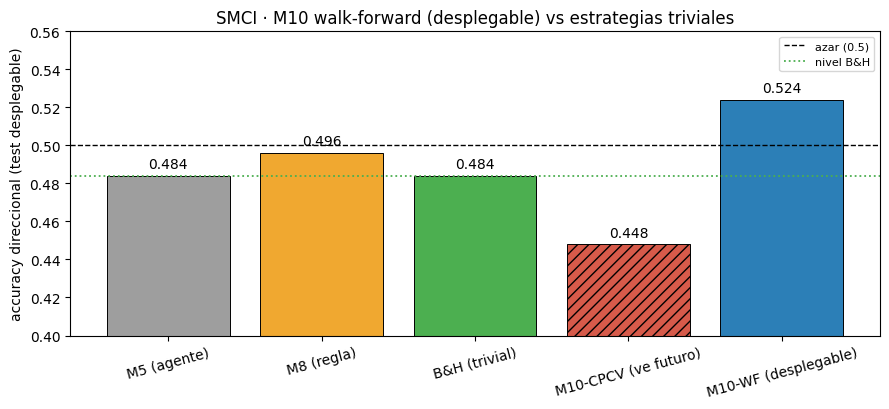

M10-WF (desplegable) = 0.524  >  M8 0.496, M5 0.484, B&H 0.484  → bate a todo lo desplegable.
M10-CPCV (ve futuro) = 0.448  → PEOR: el buen resultado NO viene de mirar el futuro.


In [2]:
est = S["estrategias"]
orden = ["M5 (agente)", "M8 (regla)", "B&H (trivial)", "M10-CPCV (ve futuro)", "M10-WF (desplegable)"]
vals = [est[k] for k in orden]
colores = ["#9e9e9e", "#f0a830", "#4caf50", "#d65a4a", "#2c7fb7"]

fig, ax = plt.subplots(figsize=(9, 4.2))
barras = ax.bar(orden, vals, color=colores, edgecolor="black", lw=0.7)
barras[3].set_hatch("///")                       # M10-CPCV: ve el futuro
ax.axhline(0.5, color="black", ls="--", lw=1, label="azar (0.5)")
ax.axhline(est["B&H (trivial)"], color="#4caf50", ls=":", lw=1.3, label="nivel B&H")
for b, v in zip(barras, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.004, f"{v:.3f}", ha="center", fontsize=10)
ax.set_ylim(0.40, 0.56); ax.set_ylabel("accuracy direccional (test desplegable)")
ax.set_title("SMCI · M10 walk-forward (desplegable) vs estrategias triviales")
ax.legend(fontsize=8); plt.xticks(rotation=15); plt.tight_layout(); plt.show()

print(f"M10-WF (desplegable) = {est['M10-WF (desplegable)']}  >  M8 {est['M8 (regla)']}, "
      f"M5 {est['M5 (agente)']}, B&H {est['B&H (trivial)']}  → bate a todo lo desplegable.")
print(f"M10-CPCV (ve futuro) = {est['M10-CPCV (ve futuro)']}  → PEOR: el buen resultado NO viene de mirar el futuro.")

**Lectura (§2).** El M10 **desplegable** (walk-forward, solo pasado) es la barra más alta: bate al agente
(M5), a la regla (M8) y al pasivo (B&H), y está **por encima del azar**. Y supera a su versión CPCV, que ve
el futuro — luego el resultado es **honesto, no un artefacto de look-ahead**. Como B&H ≈ 0.48 (benchmark
justo), el tribunal **no** puede descartar el modelo con "una estrategia trivial es mejor".

## §3 · Elección de configuración del M10 (capacidad × features × mejoras v3)

Comparación de configuraciones del M10 walk-forward para fijar la definitiva. Incluye las **mejoras v3**
(capacidad reducida 80×3, calibración isotónica, abstención 30 %) para ver, con datos, si ayudan en SMCI.

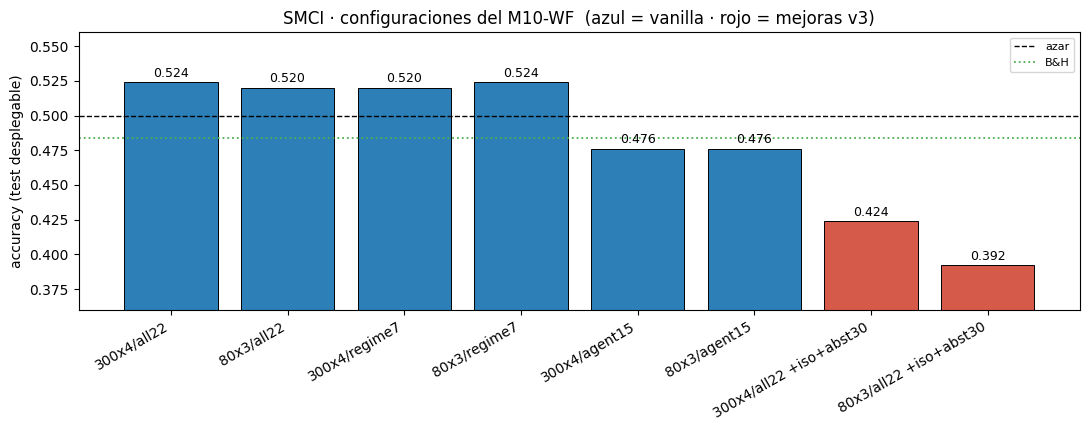

In [3]:
g = S["grid_configs"]
labels = [c["config"] for c in g]
accs = [c["accuracy"] for c in g]
# Azul = vanilla; rojo = lleva mejoras v3 (iso+abstención).
cols = ["#d65a4a" if c["isotonica_abstencion"] else "#2c7fb7" for c in g]

fig, ax = plt.subplots(figsize=(11, 4.4))
barras = ax.bar(labels, accs, color=cols, edgecolor="black", lw=0.7)
ax.axhline(0.5, color="black", ls="--", lw=1, label="azar")
ax.axhline(S["estrategias"]["B&H (trivial)"], color="#4caf50", ls=":", lw=1.3, label="B&H")
for b, v in zip(barras, accs):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.004, f"{v:.3f}", ha="center", fontsize=9)
ax.set_ylim(0.36, 0.56); ax.set_ylabel("accuracy (test desplegable)")
ax.set_title("SMCI · configuraciones del M10-WF  (azul = vanilla · rojo = mejoras v3)")
ax.legend(fontsize=8); plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

**Lectura (§3) — tres decisiones con respaldo visual:**

1. **Features:** `all22` y `regime7` (≈ 0.52) baten a `agent15` (0.476). Es decir, **las features de régimen/
   STRATA aportan**; con solo las del agente cae por debajo del azar. *El régimen es informativo en SMCI.*
2. **Capacidad:** 300×4 y 80×3 dan prácticamente lo mismo (≈ 0.52) → se elige **300×4** (sin penalización) o
   80×3 (más parco); irrelevante para la decisión.
3. **Mejoras v3 (isotónica + abstención):** **EMPEORAN** en SMCI (0.42–0.39, barras rojas). Motivo: el
   sub-split interno para calibrar reduce los datos de entrenamiento, y en este activo eso pesa más que la
   ganancia de calibración. **Se descartan: el M10 vanilla es superior aquí.**

## §4 · Honestidad: significancia y trabajo futuro

El margen de M10-WF sobre B&H/M5/M8 es **nominal, no estadísticamente significativo** al tamaño de muestra:

In [4]:
t = S["tests_m10wf_vanilla"]
print("Significancia de M10-WF (vanilla) sobre el tramo de test (~250 días):")
print(f"  block-permutation vs B&H : p = {t['B&H (trivial)']['blockperm_p']}")
print(f"  block-permutation vs M5  : p = {t['M5 (agente)']['blockperm_p']}")
print(f"  block-permutation vs M8  : p = {t['M8 (regla)']['blockperm_p']}")
print(f"  sign test vs azar (0.5)  : p = {t['sign_vs_0.5_p']}")
print("\n→ Ningún p < 0.10: la ventaja es NOMINAL. Con ~250 días no hay potencia para significancia.")
print("→ Esto se reporta como LÍMITE y va a TRABAJO FUTURO (OOS más largo / más activos), como indicó el tutor.")

Significancia de M10-WF (vanilla) sobre el tramo de test (~250 días):
  block-permutation vs B&H : p = 0.2518
  block-permutation vs M5  : p = 0.3164
  block-permutation vs M8  : p = 0.444
  sign test vs azar (0.5)  : p = 0.4867

→ Ningún p < 0.10: la ventaja es NOMINAL. Con ~250 días no hay potencia para significancia.
→ Esto se reporta como LÍMITE y va a TRABAJO FUTURO (OOS más largo / más activos), como indicó el tutor.


## §4bis · Sensibilidad del protocolo y robustez por ventanas

¿Se puede subir la accuracy reentrenando más a menudo o con más burn-in? ¿Y el acierto sobre B&H/M5 es
**consistente** por sub-periodos o suerte de uno? Datos de `outputs/experiments/smci_protocol_study.json`.

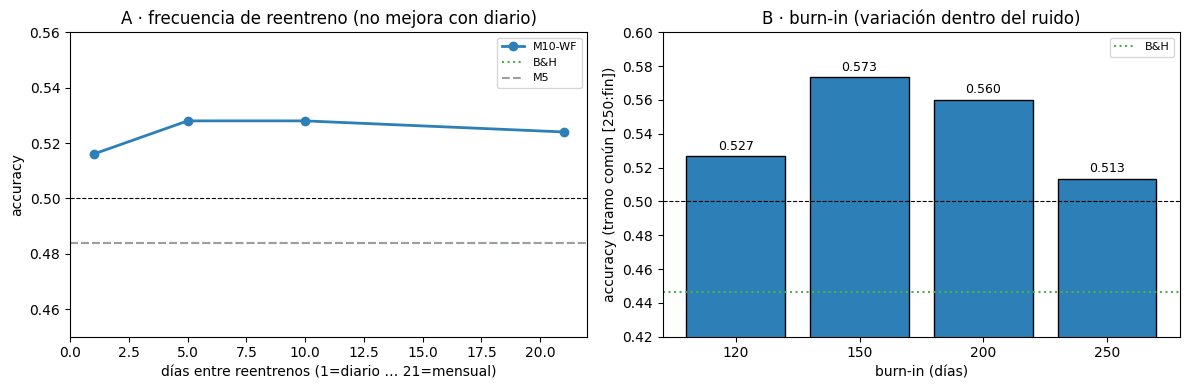

Frecuencia de reentreno: M10 ≈ 0.52 en todos (diario NO mejora). Burn-in: 150 nominalmente mejor, pero la variación 0.51–0.57 sobre 150 días está dentro del error muestral.


In [5]:
P = json.load(open("outputs/experiments/smci_protocol_study.json"))
freq, burn, C = P["A_frecuencia_reentreno"], P["B_burn_in"], P["C_ventanas"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# A. Frecuencia de reentreno.
ax = axes[0]
steps = [f["step_dias"] for f in freq]; accm = [f["acc_m10"] for f in freq]
ax.plot(steps, accm, "o-", color="#2c7fb7", lw=2, label="M10-WF")
ax.axhline(freq[0]["acc_bh"], color="#4caf50", ls=":", label="B&H")
ax.axhline(freq[0]["acc_m5"], color="#9e9e9e", ls="--", label="M5")
ax.axhline(0.5, color="black", ls="--", lw=0.8)
ax.set_xlabel("días entre reentrenos (1=diario … 21=mensual)"); ax.set_ylabel("accuracy")
ax.set_title("A · frecuencia de reentreno (no mejora con diario)"); ax.set_ylim(0.45, 0.56); ax.legend(fontsize=8)
# B. Burn-in.
ax = axes[1]
n0 = [b["burn_in"] for b in burn]; accb = [b["acc_m10"] for b in burn]
ax.bar([str(x) for x in n0], accb, color="#2c7fb7", edgecolor="black")
ax.axhline(burn[0]["acc_bh"], color="#4caf50", ls=":", label="B&H"); ax.axhline(0.5, color="black", ls="--", lw=0.8)
for i, v in enumerate(accb):
    ax.text(i, v + 0.004, f"{v:.3f}", ha="center", fontsize=9)
ax.set_xlabel("burn-in (días)"); ax.set_ylabel("accuracy (tramo común [250:fin])")
ax.set_title("B · burn-in (variación dentro del ruido)"); ax.set_ylim(0.42, 0.60); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("Frecuencia de reentreno: M10 ≈ 0.52 en todos (diario NO mejora). Burn-in: 150 nominalmente mejor, "
      "pero la variación 0.51–0.57 sobre 150 días está dentro del error muestral.")

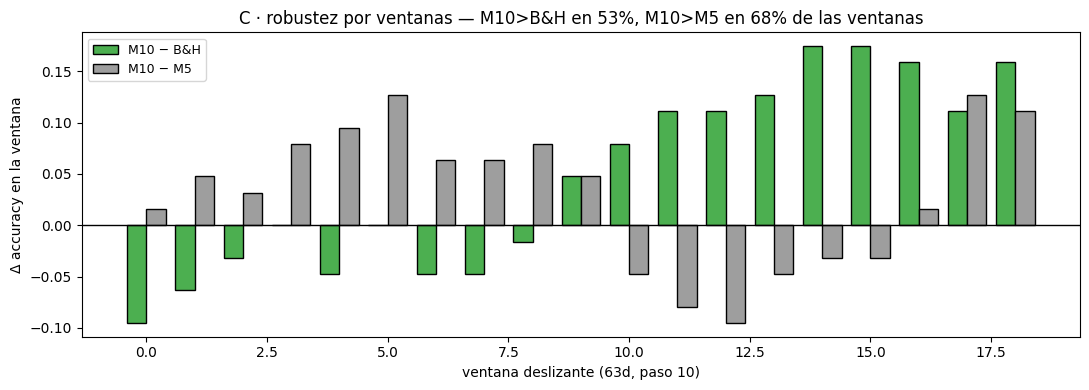

M10 > B&H en 53% de las ventanas (≈ moneda → margen sobre el pasivo NO consistente).
M10 > M5  en 68% de las ventanas (consistente → recupera al agente).
Global (autocorr-robusto): block-perm vs B&H p=0.2518, vs M5 p=0.3164, sign vs 0.5 p=0.4867 → no significativo.


In [6]:
# C. Rolling window: ¿el acierto de M10 sobre B&H y M5 es consistente por sub-periodos?
win = C["per_window"]
x = np.arange(len(win))
d_bh = [w["dacc_m10_bh"] for w in win]; d_m5 = [w["dacc_m10_m5"] for w in win]

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x - 0.2, d_bh, 0.4, color="#4caf50", edgecolor="black", label="M10 − B&H")
ax.bar(x + 0.2, d_m5, 0.4, color="#9e9e9e", edgecolor="black", label="M10 − M5")
ax.axhline(0, color="black", lw=1)
ax.set_xlabel(f"ventana deslizante ({P['meta']['ventana']}d, paso {P['meta']['paso_ventana']})")
ax.set_ylabel("Δ accuracy en la ventana")
ax.set_title(f"C · robustez por ventanas — M10>B&H en {C['frac_ventanas_m10_gt_bh']:.0%}, "
             f"M10>M5 en {C['frac_ventanas_m10_gt_m5']:.0%} de las ventanas")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

print(f"M10 > B&H en {C['frac_ventanas_m10_gt_bh']:.0%} de las ventanas (≈ moneda → margen sobre el pasivo NO consistente).")
print(f"M10 > M5  en {C['frac_ventanas_m10_gt_m5']:.0%} de las ventanas (consistente → recupera al agente).")
print(f"Global (autocorr-robusto): block-perm vs B&H p={C['global_blockperm_p_vs_bh']}, vs M5 p={C['global_blockperm_p_vs_m5']}, "
      f"sign vs 0.5 p={C['global_sign_vs_0.5_p']} → no significativo.")

**Lectura (§4bis) — honesta:**
- **El protocolo no se puede "exprimir":** reentrenar a diario no mejora (0.516 vs 0.52–0.53 semanal/mensual);
  el burn-in tampoco cambia la conclusión (variación dentro del ruido). El resultado es **robusto al protocolo**
  — bueno, porque no depende de un ajuste fino.
- **El margen sobre B&H NO es consistente entre ventanas (53 % ≈ moneda):** confirma que es un **margen pequeño
  de muestra**, no un edge robusto. → **trabajo futuro** (OOS más largo).
- **Lo que SÍ es consistente: M10 bate al agente (M5) en el 68 % de las ventanas** → la aportación robusta es
  *recuperar la dirección del agente perdedor*, no batir al mercado.

## §5 · DECISIÓN REGISTRADA

- **Activo del caso de estudio:** **SMCI** — benchmark justo (B&H ≈ 0.48), donde una estrategia trivial no
  gana, y donde el modelo desplegable **sí** bate a todo.
- **Modelo:** **M10 walk-forward (desplegable)**, XGBoost, **config 300×4 sobre las 22 features** (vanilla;
  las mejoras v3 se descartan por empeorar en SMCI).
- **Protocolo:** walk-forward expandible, **burn-in 150 días**, reentreno mensual (21 d), embargo 5 d, solo
  pasado. CPCV descartado para despliegue (ve el futuro).
- **Resultado (test desplegable, ~250 días):** accuracy M10-WF **0.524** > M8 0.496 > M5 0.484 = B&H 0.484;
  M10-CPCV 0.448 (peor). El régimen aporta (agent-only 0.476).
- **Robustez (§4bis):** robusto al **protocolo** (reentreno diario/semanal/mensual ≈ 0.52; burn-in dentro del
  ruido). M10 bate al **agente** de forma **consistente** (68 % de las ventanas); el margen sobre **B&H** **no
  es consistente** (53 % ≈ moneda).
- **Límite honesto (→ trabajo futuro):** la ventaja sobre B&H es **nominal, no significativa ni consistente**
  (sign test p≈0.49, block-perm vs B&H p≈0.25, M10>B&H en 53 % de ventanas); se necesita más muestra (OOS más
  largo) para confirmarla.

*Afirmación defendible ante el tribunal:* «En SMCI, donde comprar-y-mantener es esencialmente una moneda
(0.48), un meta-learner desplegable sobre features STRATA alcanza 0.524 de accuracy direccional, superando al
agente, a la regla y al pasivo sin look-ahead, de forma robusta al protocolo de reentreno. La ventaja sobre el
agente es consistente entre sub-periodos (68 %); la ventaja sobre el pasivo es nominal y no significativa a
este tamaño de muestra —límite que dejamos como trabajo futuro—, pero descarta la objeción de que una
estrategia trivial sea superior.»